## Imports & Setup

In [1]:
!pip install -q lightgbm xgboost catboost shap

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.metrics import balanced_accuracy_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import shap

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('viridis')

SEED = 42
N_FOLDS = 5
np.random.seed(SEED)
print(' Setup complete')

 Setup complete


##  Load Data

In [3]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')
sub   = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv')

print(f'Train: {train.shape} | Test: {test.shape}')
print(f'\nTarget counts:')
print(train['Irrigation_Need'].value_counts())
train.head()

Train: (630000, 21) | Test: (270000, 20)

Target counts:
Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


## Phase 1 — EDA

### 2.1 Target Distribution & Class Balance

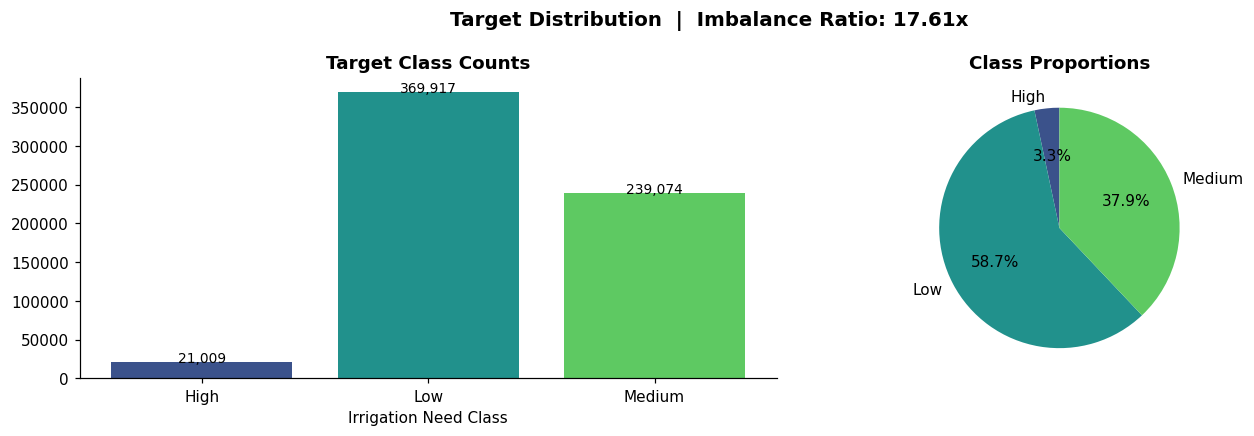

Imbalance Ratio: 17.61x
 Imbalanced dataset → Balanced Accuracy is the correct metric (not standard Accuracy).


In [4]:
target_counts = train['Irrigation_Need'].value_counts().sort_index()
imbalance_ratio = target_counts.max() / target_counts.min()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bars = axes[0].bar(target_counts.index.astype(str), target_counts.values,
                   color=sns.color_palette('viridis', len(target_counts)))
axes[0].set_title('Target Class Counts', fontweight='bold')
axes[0].set_xlabel('Irrigation Need Class')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{bar.get_height():,.0f}', ha='center', fontsize=9)

axes[1].pie(target_counts.values, labels=target_counts.index.astype(str),
            autopct='%1.1f%%', colors=sns.color_palette('viridis', len(target_counts)), startangle=90)
axes[1].set_title('Class Proportions', fontweight='bold')

plt.suptitle(f'Target Distribution  |  Imbalance Ratio: {imbalance_ratio:.2f}x', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Imbalance Ratio: {imbalance_ratio:.2f}x')
if imbalance_ratio > 1.5:
    print(' Imbalanced dataset → Balanced Accuracy is the correct metric (not standard Accuracy).')

### 2.2 Feature Distributions

Numerical (11): ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
Categorical (8): ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']


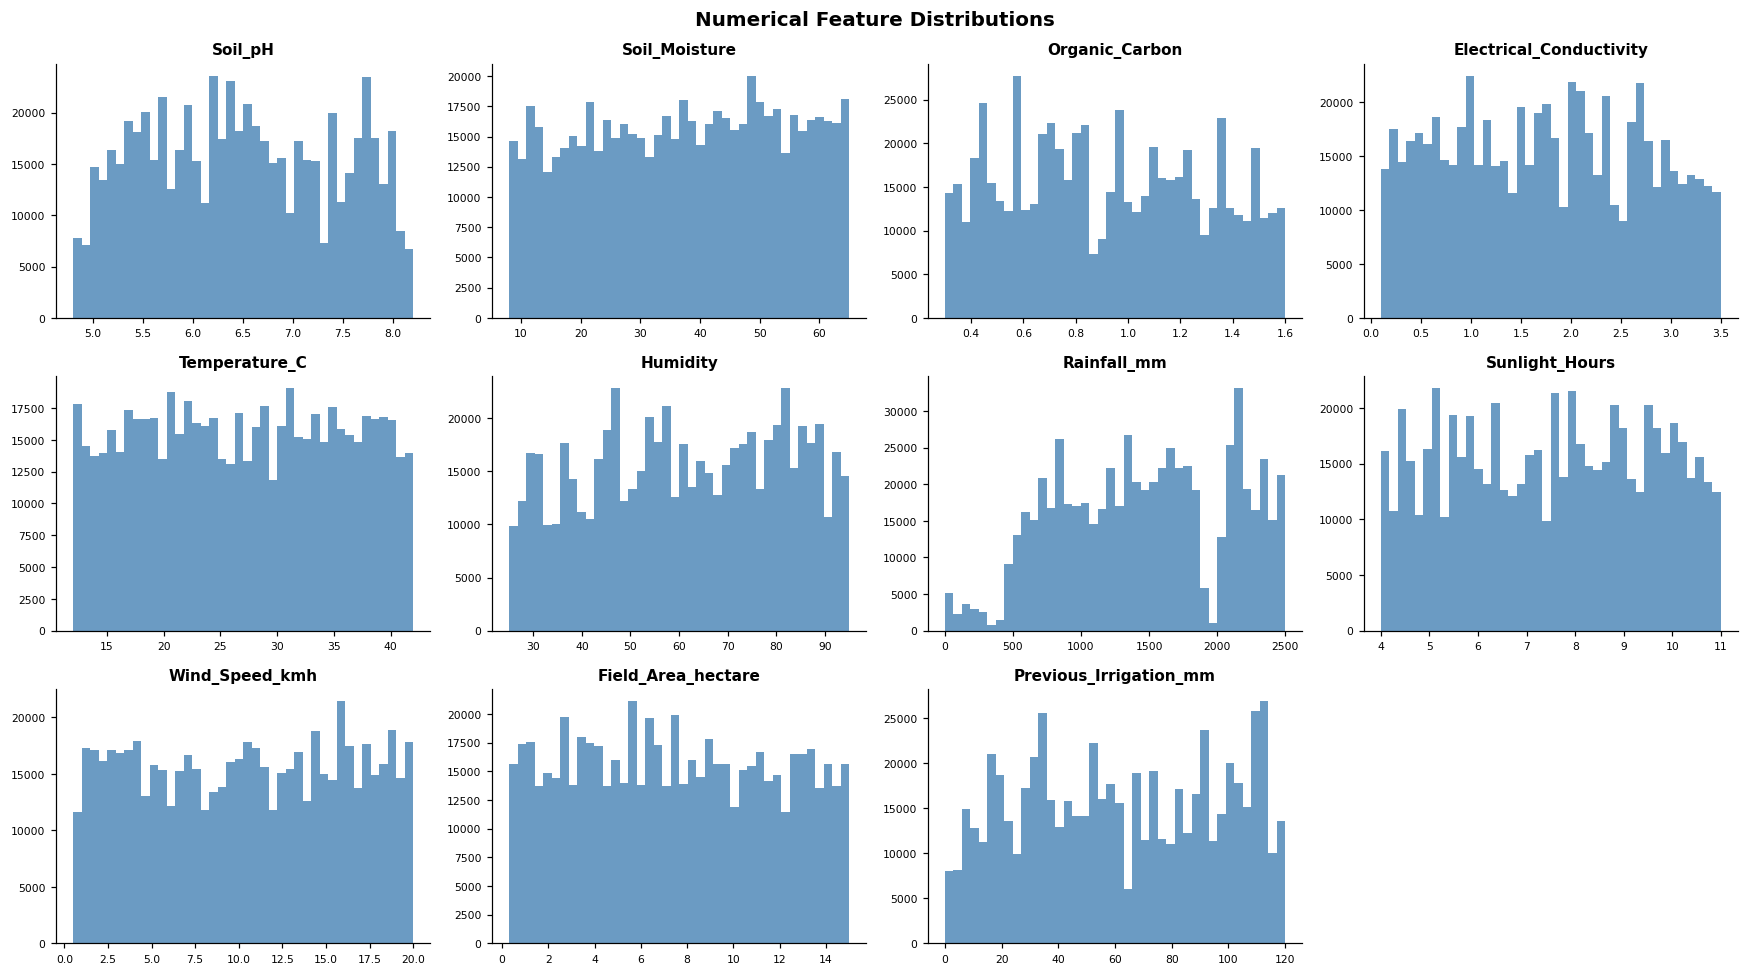

In [5]:
num_cols = [c for c in train.select_dtypes(include=np.number).columns if c not in ['id', 'Irrigation_Need']]
cat_cols = [c for c in train.select_dtypes(include='object').columns if c != 'Irrigation_Need']

print(f'Numerical ({len(num_cols)}): {num_cols}')
print(f'Categorical ({len(cat_cols)}): {cat_cols}')

ncols = 4
nrows = (len(num_cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(train[col].dropna(), bins=40, color='steelblue', alpha=0.8, edgecolor='none')
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].tick_params(labelsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

###  Correlation Heatmap

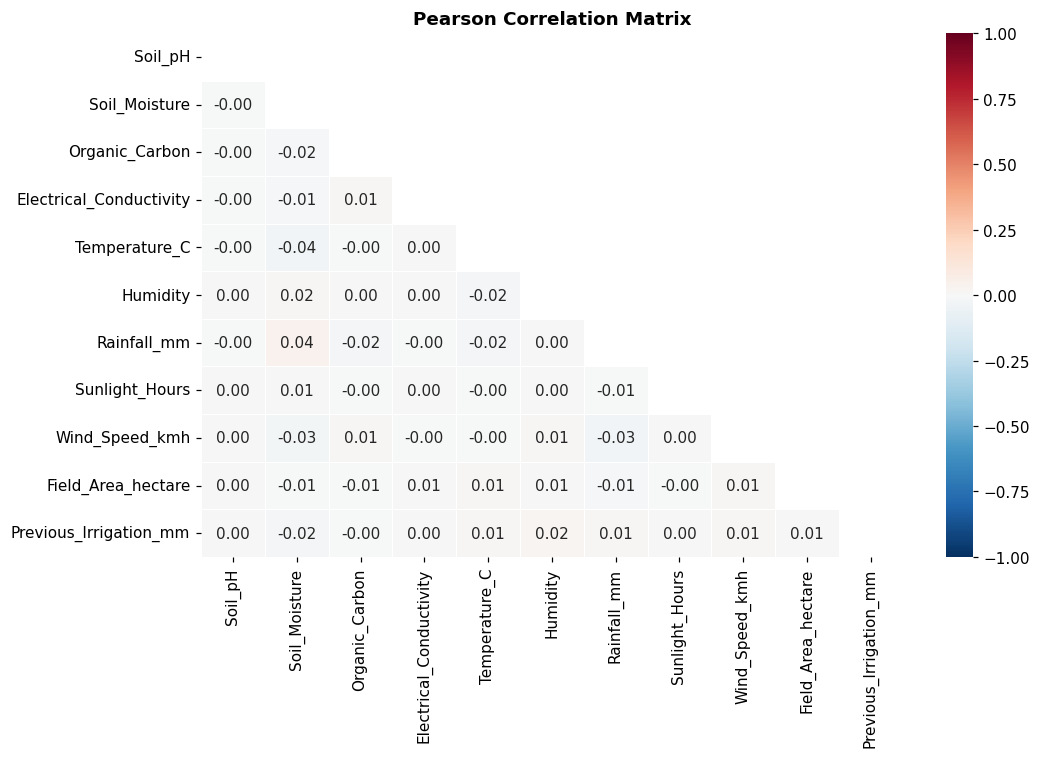

Highly correlated pairs (|r| ≥ 0.75): 0


In [6]:
corr = train[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            annot=(len(num_cols) <= 15), fmt='.2f',
            linewidths=0.4, ax=ax, vmin=-1, vmax=1)
ax.set_title('Pearson Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Report high correlations
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = [(col, row, val) for col in upper.columns
             for row, val in upper[col].items() if abs(val) >= 0.75]
high_corr_df = pd.DataFrame(high_corr, columns=['Feature A', 'Feature B', 'r']).sort_values('r', key=abs, ascending=False)
print(f'Highly correlated pairs (|r| ≥ 0.75): {len(high_corr_df)}')
if len(high_corr_df):
    print(high_corr_df.to_string(index=False))

##  Phase 2 — Preprocessing & Feature Engineering

### Multicollinearity (VIF)

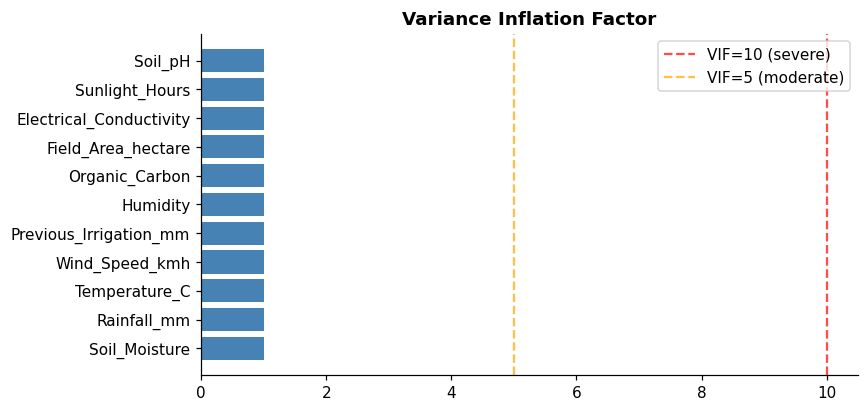

                Feature      VIF
          Soil_Moisture 1.005214
            Rainfall_mm 1.003902
          Temperature_C 1.002282
         Wind_Speed_kmh 1.002223
 Previous_Irrigation_mm 1.001325
               Humidity 1.001192
         Organic_Carbon 1.000805
     Field_Area_hectare 1.000580
Electrical_Conductivity 1.000287
         Sunlight_Hours 1.000120
                Soil_pH 1.000083

High-VIF (>10): []

 Decision: Keep all features for tree models (univariate splits are immune to multicollinearity).
   LogReg baseline uses PCA to handle it.


In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_vif = add_constant(train[num_cols].dropna())
vif_df = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).query('Feature != "const"').sort_values('VIF', ascending=False)

fig, ax = plt.subplots(figsize=(8, max(3, len(num_cols) * 0.35)))
colors = ['crimson' if v > 10 else 'orange' if v > 5 else 'steelblue' for v in vif_df['VIF']]
ax.barh(vif_df['Feature'], vif_df['VIF'], color=colors)
ax.axvline(10, color='red', ls='--', alpha=0.7, label='VIF=10 (severe)')
ax.axvline(5,  color='orange', ls='--', alpha=0.7, label='VIF=5 (moderate)')
ax.legend(); ax.set_title('Variance Inflation Factor', fontweight='bold')
plt.tight_layout(); plt.show()

print(vif_df.to_string(index=False))
high_vif_feats = vif_df[vif_df['VIF'] > 10]['Feature'].tolist()
print(f'\nHigh-VIF (>10): {high_vif_feats}')
print('\n Decision: Keep all features for tree models (univariate splits are immune to multicollinearity).')
print('   LogReg baseline uses PCA to handle it.')

###  Encode & Combine

In [8]:
TARGET = 'Irrigation_Need'
le_target = LabelEncoder()
y_enc = le_target.fit_transform(train[TARGET])
n_classes = len(le_target.classes_)
print(f'Classes: {le_target.classes_}')

drop_cols = [TARGET] + (['id'] if 'id' in train.columns else [])
X_train_raw = train.drop(columns=drop_cols)
X_test_raw  = test.drop(columns=['id'] if 'id' in test.columns else [])
test_ids    = test['id'] if 'id' in test.columns else pd.RangeIndex(len(test))

all_data = pd.concat([X_train_raw, X_test_raw], axis=0, ignore_index=True)

# Label-encode categoricals (efficient for tree models)
for col in cat_cols:
    le = LabelEncoder()
    all_data[col] = le.fit_transform(all_data[col].astype(str))

print(f'Combined data shape: {all_data.shape}')

Classes: ['High' 'Low' 'Medium']
Combined data shape: (900000, 19)


###  Feature Engineering

In [9]:
def engineer_features(df):
    df = df.copy()
    c = df.columns.tolist()

    # Agro-environmental interactions
    if 'Temperature' in c and 'Humidity' in c:
        df['heat_stress']         = df['Temperature'] * (1 - df['Humidity'] / 100)
        df['temp_humidity_ratio'] = df['Temperature'] / (df['Humidity'] + 1e-6)

    if 'Soil_Moisture' in c and 'Temperature' in c:
        df['evapotransp_proxy']    = df['Soil_Moisture'] * df['Temperature']
        df['soil_temp_ratio']      = df['Soil_Moisture'] / (df['Temperature'] + 1e-6)

    if 'Wind_Speed' in c and 'Humidity' in c:
        df['moisture_loss_proxy'] = df['Wind_Speed'] * (100 - df['Humidity'])

    if 'Rainfall' in c and 'Soil_Moisture' in c:
        df['rainfall_deficit']    = df['Soil_Moisture'] - df['Rainfall']
        df['rainfall_soil_sum']   = df['Rainfall'] + df['Soil_Moisture']

    if 'Solar_Radiation' in c and 'Humidity' in c:
        df['solar_humidity_ratio'] = df['Solar_Radiation'] / (df['Humidity'] + 1e-6)

    # Row-level statistics
    base_num = [col for col in num_cols if col in df.columns]
    df['row_mean']  = df[base_num].mean(axis=1)
    df['row_std']   = df[base_num].std(axis=1)
    df['row_range'] = df[base_num].max(axis=1) - df[base_num].min(axis=1)

    return df

all_data = engineer_features(all_data)
new_feats = [c for c in all_data.columns if c not in X_train_raw.columns]
print(f'Engineered {len(new_feats)} new features: {new_feats}')

Engineered 3 new features: ['row_mean', 'row_std', 'row_range']


### Impute & Split

In [10]:
# Median imputation — robust to skewed distributions in sensor data
imputer = SimpleImputer(strategy='median')
all_arr = imputer.fit_transform(all_data)
all_data = pd.DataFrame(all_arr, columns=all_data.columns)

n_train = len(X_train_raw)
X_train = all_data.iloc[:n_train].reset_index(drop=True)
X_test  = all_data.iloc[n_train:].reset_index(drop=True)
feature_names = X_train.columns.tolist()

# RobustScaler for the linear baseline only
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'Missing values: {all_data.isnull().sum().sum()}')

X_train: (630000, 22), X_test: (270000, 22)
Missing values: 0


## Phase 3 — Model Development

### CV Helper

In [11]:
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
results = {}

def evaluate_model(model, X, y, name):
    ba_scores, acc_scores = [], []
    for tr_idx, val_idx in cv.split(X, y):
        model.fit(X[tr_idx], y[tr_idx])
        preds = model.predict(X[val_idx])
        ba_scores.append(balanced_accuracy_score(y[val_idx], preds))
        acc_scores.append(accuracy_score(y[val_idx], preds))
    results[name] = {'BA': np.mean(ba_scores), 'BA_std': np.std(ba_scores), 'Acc': np.mean(acc_scores)}
    print(f'{name:<35} | Balanced Acc: {np.mean(ba_scores):.4f} ± {np.std(ba_scores):.4f} | Acc: {np.mean(acc_scores):.4f}')
    return ba_scores

### 4.2 Model 1 — Logistic Regression  

In [12]:
# Uses PCA to handle multicollinearity
# Justification: linear models need orthogonal features; PCA(0.99) retains 99% variance
lr = make_pipeline(
    PCA(n_components=0.99, random_state=SEED),
    LogisticRegression(max_iter=2000, class_weight='balanced', C=1.0, random_state=SEED)
)
evaluate_model(lr, X_train_scaled, y_enc, 'Logistic Regression (PCA baseline)')

Logistic Regression (PCA baseline)  | Balanced Acc: 0.7357 ± 0.0024 | Acc: 0.6976


[np.float64(0.7377503214247132),
 np.float64(0.7378417456757408),
 np.float64(0.7367191374530503),
 np.float64(0.7348808800112439),
 np.float64(0.731354772734064)]

###  Model 2 — Random Forest

In [13]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=SEED
)
evaluate_model(rf, X_train.values, y_enc, 'Random Forest')

Random Forest                       | Balanced Acc: 0.9619 ± 0.0005 | Acc: 0.9852


[np.float64(0.9611560100052735),
 np.float64(0.96176008748085),
 np.float64(0.9625955337850426),
 np.float64(0.9618315492413898),
 np.float64(0.961926945754494)]

### Model 3 — LightGBM

In [14]:
# Well-tuned defaults — fast and strong for tabular data
lgbm = lgb.LGBMClassifier(
    n_estimators=800,
    learning_rate=0.05,
    num_leaves=127,
    max_depth=8,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    class_weight='balanced',
    verbosity=-1,
    random_state=SEED,
    n_jobs=-1
)
evaluate_model(lgbm, X_train.values, y_enc, 'LightGBM')

LightGBM                            | Balanced Acc: 0.9650 ± 0.0009 | Acc: 0.9843


[np.float64(0.9647976570992108),
 np.float64(0.9654181634267411),
 np.float64(0.9661018292238298),
 np.float64(0.9634102389685936),
 np.float64(0.9652666046075223)]

###  Model 4 — XGBoost

In [15]:
from sklearn.utils.class_weight import compute_sample_weight
sw = compute_sample_weight('balanced', y_enc)

xgb_model = xgb.XGBClassifier(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='multi:softmax',
    num_class=n_classes,
    use_label_encoder=False,
    eval_metric='mlogloss',
    tree_method='hist',
    random_state=SEED,
    n_jobs=-1
)

# Manual CV to pass sample_weight
ba_scores, acc_scores = [], []
for tr_idx, val_idx in cv.split(X_train.values, y_enc):
    xgb_model.fit(X_train.values[tr_idx], y_enc[tr_idx],
                  sample_weight=sw[tr_idx])
    preds = xgb_model.predict(X_train.values[val_idx])
    ba_scores.append(balanced_accuracy_score(y_enc[val_idx], preds))
    acc_scores.append(accuracy_score(y_enc[val_idx], preds))

results['XGBoost'] = {'BA': np.mean(ba_scores), 'BA_std': np.std(ba_scores), 'Acc': np.mean(acc_scores)}
print(f'{"XGBoost":<35} | Balanced Acc: {np.mean(ba_scores):.4f} ± {np.std(ba_scores):.4f} | Acc: {np.mean(acc_scores):.4f}')

XGBoost                             | Balanced Acc: 0.9695 ± 0.0009 | Acc: 0.9846


###  Model 5 — CatBoost

In [16]:
cat_model = CatBoostClassifier(
    iterations=800,
    learning_rate=0.05,
    depth=7,
    l2_leaf_reg=3,
    bootstrap_type='Bernoulli',   
    subsample=0.8,
    colsample_bylevel=0.8,
    auto_class_weights='Balanced',
    loss_function='MultiClass',
    verbose=0,
    random_seed=SEED
)
evaluate_model(cat_model, X_train.values, y_enc, 'CatBoost')

CatBoost                            | Balanced Acc: 0.9696 ± 0.0009 | Acc: 0.9821


[np.float64(0.968486770859028),
 np.float64(0.9706390383441801),
 np.float64(0.9706512698064219),
 np.float64(0.968902717897569),
 np.float64(0.9694863483348994)]

## Phase 4 — Evaluation & Ensemble

###   Model Comparison

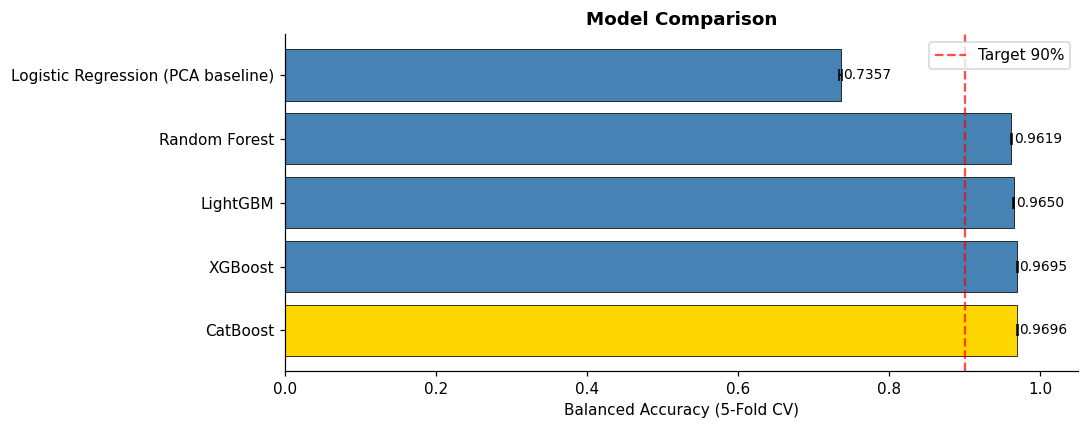

                             Model  Balanced Accuracy      Std  Accuracy
                          CatBoost           0.969633 0.000885  0.982068
                           XGBoost           0.969489 0.000890  0.984595
                          LightGBM           0.964999 0.000898  0.984349
                     Random Forest           0.961854 0.000459  0.985202
Logistic Regression (PCA baseline)           0.735709 0.002424  0.697589


In [17]:
res_df = pd.DataFrame(results).T.reset_index()
res_df.columns = ['Model', 'Balanced Accuracy', 'Std', 'Accuracy']
res_df = res_df.sort_values('Balanced Accuracy', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(res_df))]
bars = ax.barh(res_df['Model'], res_df['Balanced Accuracy'],
               xerr=res_df['Std'], capsize=4, color=colors, edgecolor='black', lw=0.5)
ax.axvline(0.9, color='red', ls='--', alpha=0.7, label='Target 90%')
ax.set_xlim(0, 1.05)
ax.set_xlabel('Balanced Accuracy (5-Fold CV)')
ax.set_title('Model Comparison', fontweight='bold')
for bar, v in zip(bars, res_df['Balanced Accuracy']):
    ax.text(v + 0.003, bar.get_y() + bar.get_height()/2, f'{v:.4f}', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

print(res_df.to_string(index=False))

### Soft-Voting Ensemble (Best 3 Models)

In [18]:
# Soft-voting ensemble: average predicted probabilities across the three best tree models
# Each model is refit on the full training set for final predictions

best_models = {'lgbm': lgbm, 'catboost': cat_model, 'xgboost': xgb_model}

oof_probas  = {k: np.zeros((len(X_train), n_classes)) for k in best_models}
test_probas = {k: np.zeros((len(X_test),  n_classes)) for k in best_models}

for name, model in best_models.items():
    fold_test = []
    for tr_idx, val_idx in cv.split(X_train.values, y_enc):
        kw = {'sample_weight': sw[tr_idx]} if name == 'xgboost' else {}
        model.fit(X_train.values[tr_idx], y_enc[tr_idx], **kw)
        oof_probas[name][val_idx] = model.predict_proba(X_train.values[val_idx])
        fold_test.append(model.predict_proba(X_test.values))
    test_probas[name] = np.mean(fold_test, axis=0)

# Average probabilities
avg_oof_proba  = np.mean(list(oof_probas.values()), axis=0)
avg_test_proba = np.mean(list(test_probas.values()), axis=0)

oof_ensemble_preds = np.argmax(avg_oof_proba, axis=1)
ensemble_ba  = balanced_accuracy_score(y_enc, oof_ensemble_preds)
ensemble_acc = accuracy_score(y_enc, oof_ensemble_preds)

print(f'   Soft-Voting Ensemble OOF Balanced Accuracy: {ensemble_ba:.4f}')
print(f'   Soft-Voting Ensemble OOF Accuracy         : {ensemble_acc:.4f}')
 

   Soft-Voting Ensemble OOF Balanced Accuracy: 0.9682
   Soft-Voting Ensemble OOF Accuracy         : 0.9847


### Confusion Matrix

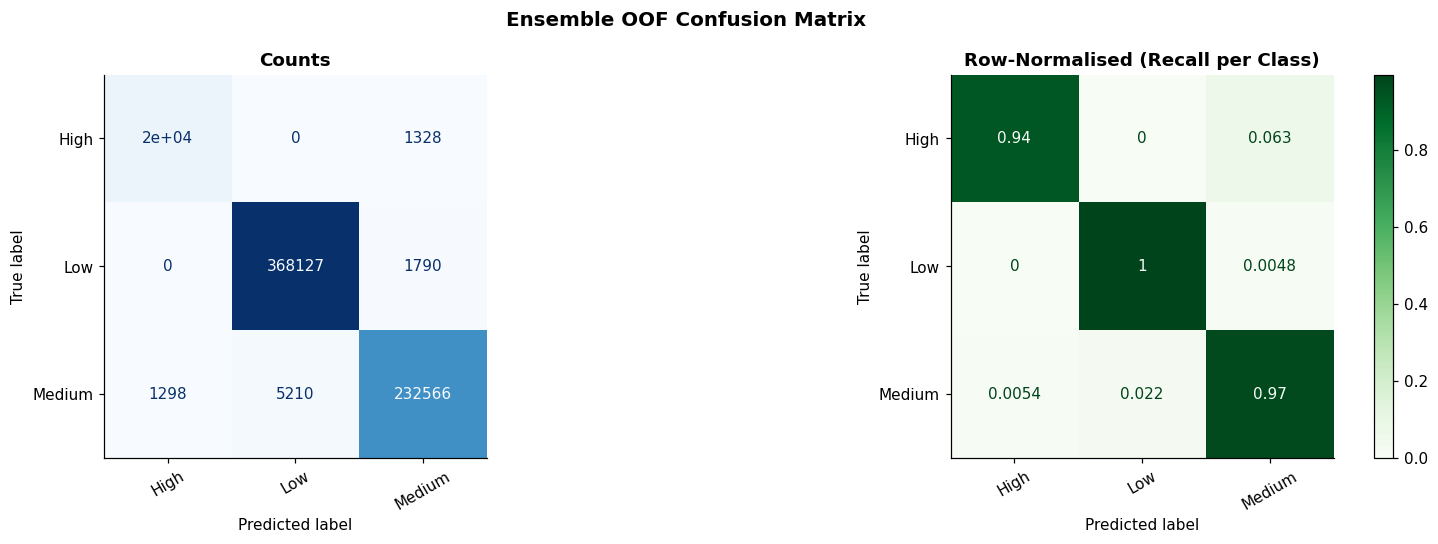

              precision    recall  f1-score   support

        High       0.94      0.94      0.94     21009
         Low       0.99      1.00      0.99    369917
      Medium       0.99      0.97      0.98    239074

    accuracy                           0.98    630000
   macro avg       0.97      0.97      0.97    630000
weighted avg       0.98      0.98      0.98    630000



In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cm = confusion_matrix(y_enc, oof_ensemble_preds)
ConfusionMatrixDisplay(cm, display_labels=le_target.classes_).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Counts', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

cm_norm = confusion_matrix(y_enc, oof_ensemble_preds, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=le_target.classes_).plot(ax=axes[1], cmap='Greens', colorbar=True)
axes[1].set_title('Row-Normalised (Recall per Class)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Ensemble OOF Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(classification_report(y_enc, oof_ensemble_preds, target_names=le_target.classes_.astype(str)))

## Submission

In [ ]:
# Refit each model ONCE on full training data, predict test directly — no re-CV
best_models = {'lgbm': lgbm, 'catboost': cat_model, 'xgboost': xgb_model}
test_probas = []

for name, model in best_models.items():
    kw = {'sample_weight': sw} if name == 'xgboost' else {}
    model.fit(X_train.values, y_enc, **kw)
    test_probas.append(model.predict_proba(X_test.values))

avg_test_proba = np.mean(test_probas, axis=0)
final_preds    = le_target.inverse_transform(np.argmax(avg_test_proba, axis=1))

submission = pd.DataFrame({'id': test_ids.values, 'Irrigation_Need': final_preds})
submission.to_csv('submission.csv', index=False)
print(' submission.csv saved')
print(submission['Irrigation_Need'].value_counts())
submission.head()

In [ ]:
submission

## Summary

In [ ]:
print('=' * 60)
print('             FINAL RESULTS SUMMARY')
print('=' * 60)
for _, row in res_df.iterrows():
    print(f"  {row['Model']:<35} → {row['Balanced Accuracy']:.4f} ± {row['Std']:.4f}")
print(f"  {'Soft-Voting Ensemble (OOF)':<35} → {ensemble_ba:.4f}")
print(f'\n  {' TARGET HIT (≥0.90)' if ensemble_ba >= 0.90 else  Close — test set may cross 90%'}')
print('=' * 60)
print(f'\nEngineered features: {new_feats}')

---
## Justification Table

| Choice | Justification |
|---|---|
| **RobustScaler** | Median/IQR-based — robust to sensor outliers |
| **Label Encoding** for trees | Tree splits are univariate; OHE wastes dimensions |
| **PCA + LogReg** | Linear models need orthogonal features; PCA removes multicollinearity |
| **Keep VIF features** for trees | Tree models are immune to multicollinearity |
| **`class_weight='balanced'`** | Penalises minority-class errors; aligns with Balanced Accuracy |
| **Soft-voting ensemble** | Averaging probabilities reduces variance vs. any single model |
| **Median imputation** | Robust to outliers in environmental sensor readings |
| **Balanced Accuracy** | $\text{BA} = \frac{1}{K}\sum_k \text{Recall}_k$ — equal weight per class, correct for imbalanced data |